# RSNA Knee Abnormality Detection — Data Exploration

In this notebook, we will understand the structure of the RSNA Knee Abnormality Detection dataset before building the transfer-learning pipeline.

We will examine:

- Study-level metadata
- Series-level metadata
- The 12 abnormality labels
- Label availability and imbalance
- Study → Series relationships
- MRI sequence information
- DICOM structure

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
data_dir = Path('data/rsna')
print("Data dir:", data_dir)
print("Exist:", data_dir.exists())
print(list(data_dir.iterdir()))

Data dir: data\rsna
Exist: True
[WindowsPath('data/rsna/train.csv'), WindowsPath('data/rsna/train_series.csv')]


In [7]:
## loading the metadat
train_df = pd.read_csv(data_dir / 'train.csv')
train_series_df = pd.read_csv(data_dir / 'train_series.csv')

In [8]:
print("train.csv shape:", train_df.shape)
print("train_series.csv shape:", train_series_df.shape)

train.csv shape: (4407, 14)
train_series.csv shape: (24371, 5)


In [12]:
display(train_df.head())
display(train_series_df.head())

,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,"In the medial compartment, the meniscus is no...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,1,1,Sagittal
1,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.13821229744997220641...,1,1,Axial
2,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.23084836536722595275...,0,0,Coronal
3,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.40734206102458723096...,1,1,Coronal
4,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.75714899997203615784...,0,0,Sagittal


In [19]:
train_df[train_df.notna().all(axis=1)].head()

,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
29,1.2.826.0.1.3680043.8.498.10095687747295410396...,Antecedentes Clínicos:\nEsguince rodilla. [DAT...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
63,1.2.826.0.1.3680043.8.498.10170898615867673028...,The study reveals normal knee joint alignment...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
109,1.2.826.0.1.3680043.8.498.10306159113324811538...,Exam Type: MRI KNEE RIGHT WO CONTRAST\nExam Da...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
445,1.2.826.0.1.3680043.8.498.11287937729196958426...,"MRI of left Knee with \n-3-Plane Loc R'T, Sag ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
470,1.2.826.0.1.3680043.8.498.11382021393803389951...,"In the medial compartment, there is longitudi...",1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
print("Train_csv columns:")
print(train_df.columns.to_list())

print("\ntrain_series.csv columns")
print(train_series_df.columns.to_list())

Train_csv columns:
['StudyInstanceUID', 'Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']

train_series.csv columns
['StudyInstanceUID', 'SeriesInstanceUID', 'Fluid_Sensitive', 'Fat_Suppression', 'Anatomical_Plane']


In [30]:
## Checking for unique counts

print("Number of studies:", train_df['StudyInstanceUID'].nunique())
print("Number of series:", train_series_df['SeriesInstanceUID'].nunique())

Number of studies: 4407
Number of series: 24371


In [31]:
## Checking for total counts

print("Rows in train.csv:", len(train_df))
print("Rows in train_series.csv:", len(train_series_df))

Rows in train.csv: 4407
Rows in train_series.csv: 24371


In [32]:
## Checking the number of unique series per study 

series_per_study = (
    train_series_df
    .groupby('StudyInstanceUID')['SeriesInstanceUID']
    .nunique()
)

print(series_per_study.describe())

count    4407.000000
mean        5.530066
std         1.393826
min         3.000000
25%         5.000000
50%         5.000000
75%         6.000000
max        14.000000
Name: SeriesInstanceUID, dtype: float64


In [33]:
series_per_study.value_counts().sort_index()

SeriesInstanceUID
3        1
4      675
5     2299
6      698
7      310
8      145
9      176
10      74
11      21
12       5
13       2
14       1
Name: count, dtype: int64

In [34]:
## Checking how many studies are labeled

label_cols = [
    "ACL",
    "MCL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "Medial OA",
    "Lateral OA",
    "PF OA",
    "Effusion",
    "Synovitis",
    "Baker's",
    "Contusion",
    "Fracture",
]

print("Number of targets:", len(label_cols))

Number of targets: 12


In [35]:
train_df[label_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4407 entries, 0 to 4406
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ACL               58 non-null     float64
 1   MCL               58 non-null     float64
 2   Medial Meniscus   58 non-null     float64
 3   Lateral Meniscus  58 non-null     float64
 4   Medial OA         58 non-null     float64
 5   Lateral OA        58 non-null     float64
 6   PF OA             58 non-null     float64
 7   Effusion          58 non-null     float64
 8   Synovitis         58 non-null     float64
 9   Baker's           58 non-null     float64
 10  Contusion         58 non-null     float64
 11  Fracture          58 non-null     float64
dtypes: float64(12)
memory usage: 413.3 KB


In [36]:
train_df[label_cols].sum()

ACL                 24.0
MCL                  9.0
Medial Meniscus     26.0
Lateral Meniscus    23.0
Medial OA           15.0
Lateral OA          11.0
PF OA               21.0
Effusion            35.0
Synovitis           27.0
Baker's             12.0
Contusion           19.0
Fracture            18.0
dtype: float64

In [40]:
## We have only 58 labelled studies
## but the good this is we have Handwritten reports for all, which can be used to generate those labels
train_df['Report'].notna().sum()

np.int64(4407)

In [41]:
report_lengths = train_df['Report'].dropna().str.len()
print('Report len statistics:')
print(report_lengths.describe())

Report len statistics:
count    4407.000000
mean     1097.905605
std       693.948925
min        52.000000
25%       587.500000
50%       977.000000
75%      1459.500000
max      4743.000000
Name: Report, dtype: float64


In [46]:
pd.set_option('display.max_colwidth', 200)                 # This will enable us to see more of the text

display(
    train_df[['StudyInstanceUID', 'Report']]
    .dropna()
    .head(10)
)

,StudyInstanceUID,Report
0,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,Técnica: RMN de la rodilla. Resultados: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cóndilo femoral medial. Artrosis femorotibial medial. Derrame. . Impresión: Rotura d...
1,1.2.826.0.1.3680043.8.498.10004945927472656027199792075652399585,"[DATE]: * MR Knie Rechts 15ch AA Klinische Inlichtingen: [DATE]. Diagnostische vraagstellling: Meniscusscheur/mediaal? Scanprotocol (DRB) : sag intermediair gewogen seq zonder en met fs, ax/ cor p..."
2,1.2.826.0.1.3680043.8.498.10009278692606631573540062909909132231,Hallazgos:\nNo hay alteraciones en significativas de la médula ósea.\nLigamentos cruzados y colaterales dentro de límites normales.\nAumento de señal del cuerno posterior del menisco medial que no...
3,1.2.826.0.1.3680043.8.498.10009639203170750274174707434356622764,"In the medial compartment, the meniscus is not torn and there is no focal chondrosis or chondral injury. \n The lateral compartment, there is suspicious incomplete discoid lateral meniscus withou..."
4,1.2.826.0.1.3680043.8.498.10013663742400736029415768216599146542,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAlignement articulaire :\nNormal.\n\nChangements dégénératifs :\nChondropatie rétropatellaire modérée à sévère avec fissuration profonde impliquant les f...
5,1.2.826.0.1.3680043.8.498.10018552945042470316597008531304016339,Antecedentes Clínicos:\nCondromalacia rotuliana.\nHallazgos:\nNo hay alteraciones difusas de señal de la médula ósea.\nLigamentos cruzados y colaterales de grosor y señal normales.\nMenisco medial...
6,1.2.826.0.1.3680043.8.498.10018749256316287542884435387067561101,"MRI of left knee with -Locator, SG PD FatSat, SG T2W FS, SG T1W, CO T2W FS, AX T2W FS\n\nFindings:\n> The contour of anterior cruciate ligament is in a straight line but increase signal intensity ..."
7,1.2.826.0.1.3680043.8.498.10021179701366615563817491713738306606,"МР находка: МР данни за ставен излив. Костите, формиращи дясната коляно са със непроменена структура. Малък костномозъчен едем локализиран в медиалния кондил на тибията. Артикулиращият хрущял на ..."
8,1.2.826.0.1.3680043.8.498.10021288557171866794624317186288618513,"SOL DİZ MRG. Tetkik protokolü: Çok düzlemli, çok sekanslı. Bulgular: Lateral menisküs ve medial menisküs normaldir. Ön çapraz bağ ve arka çapraz bağ, lateral ve medial kollateral ligaman normaldir..."
9,1.2.826.0.1.3680043.8.498.10025765742726180988537955593315007559,"MRI of left Knee with \n-Locator, SG PD FatSat, SG T1W, SG T2W FS, CO T2W FS, AX T2W FS\n\n\n> Fracture of posterior tibial intercondylar eminence with avulsion fracture of PCL.\n Bone marrow e..."


In [47]:
## Above reports tell us that the data is 'multi-lingual'
## Corpus is closer to radiology reports and classical findings

In [48]:
print("Fluid Sensitive:")
display(train_series_df["Fluid_Sensitive"].value_counts(dropna=False))

print("\nFat Suppression:")
display(train_series_df["Fat_Suppression"].value_counts(dropna=False))

print("\nAnatomical Plane:")
display(train_series_df["Anatomical_Plane"].value_counts(dropna=False))

Fluid Sensitive:


Fluid_Sensitive
1    14010
0    10361
Name: count, dtype: int64


Fat Suppression:


Fat_Suppression
1    14010
0    10361
Name: count, dtype: int64


Anatomical Plane:


Anatomical_Plane
Sagittal    9864
Coronal     8609
Axial       5898
Name: count, dtype: int64

In [49]:
display(
    train_series_df[
        ["Fluid_Sensitive", "Fat_Suppression", "Anatomical_Plane"]
    ].drop_duplicates()
)

,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1,1,Sagittal
1,1,1,Axial
2,0,0,Coronal
3,1,1,Coronal
4,0,0,Sagittal
17,0,0,Axial


In [50]:
train_series_df.value_counts(["Fluid_Sensitive", "Fat_Suppression", "Anatomical_Plane"]).reset_index(name='counts')

,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane,counts
0,0,0,Sagittal,5197
1,1,1,Axial,4719
2,1,1,Sagittal,4667
3,1,1,Coronal,4624
4,0,0,Coronal,3985
5,0,0,Axial,1179


In [51]:
## Checking how many series of each type a typical study has
series_type_count = (
    train_series_df
    .groupby(
        ['StudyInstanceUID', 'Fluid_Sensitive', 'Fat_Suppression', 'Anatomical_Plane']
    )
    .size()
    .reset_index(name='count')
)

display(series_type_count.head(20))

,StudyInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane,count
0,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,0,0,Coronal,1
1,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,0,0,Sagittal,1
2,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,1,1,Axial,1
3,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,1,1,Coronal,1
4,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,1,1,Sagittal,1
5,1.2.826.0.1.3680043.8.498.10004945927472656027199792075652399585,0,0,Coronal,1
6,1.2.826.0.1.3680043.8.498.10004945927472656027199792075652399585,0,0,Sagittal,1
7,1.2.826.0.1.3680043.8.498.10004945927472656027199792075652399585,1,1,Axial,1
8,1.2.826.0.1.3680043.8.498.10004945927472656027199792075652399585,1,1,Coronal,1
9,1.2.826.0.1.3680043.8.498.10004945927472656027199792075652399585,1,1,Sagittal,1


In [52]:
display(
    train_series_df[
        ["Fluid_Sensitive", "Fat_Suppression", "Anatomical_Plane"]
    ]
    .value_counts()
    .sort_index()
)

Fluid_Sensitive  Fat_Suppression  Anatomical_Plane
0                0                Axial               1179
                                  Coronal             3985
                                  Sagittal            5197
1                1                Axial               4719
                                  Coronal             4624
                                  Sagittal            4667
Name: count, dtype: int64

## Now we will see the actual DICOM images

In [57]:
study_id = train_series_df["StudyInstanceUID"].iloc[0]

study_series = train_series_df[
    train_series_df["StudyInstanceUID"] == study_id
]

display(study_series)

,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,1.2.826.0.1.3680043.8.498.12343110195036213483454091715412333772,1,1,Sagittal
1,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,1.2.826.0.1.3680043.8.498.13821229744997220641575291927426543265,1,1,Axial
2,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,1.2.826.0.1.3680043.8.498.23084836536722595275828690293168736174,0,0,Coronal
3,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,1.2.826.0.1.3680043.8.498.40734206102458723096154687147390476697,1,1,Coronal
4,1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260,1.2.826.0.1.3680043.8.498.75714899997203615784077798038670363546,0,0,Sagittal


In [58]:
series_id = study_series["SeriesInstanceUID"].iloc[0]

print("StudyInstanceUID:", study_id)
print("SeriesInstanceUID:", series_id)

StudyInstanceUID: 1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260
SeriesInstanceUID: 1.2.826.0.1.3680043.8.498.12343110195036213483454091715412333772


In [67]:
series_id = "1.2.826.0.1.3680043.8.498.12343110195036213483454091715412333772"

matches = [
    f.name
    for f in page.files
    if series_id in f.name
]

print("Number of DICOM slices:", len(matches))
print("First 5:")
for x in matches[:5]:
    print(x)

Number of DICOM slices: 18
First 5:
train_series/1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260/1.2.826.0.1.3680043.8.498.12343110195036213483454091715412333772/1.2.826.0.1.3680043.8.498.10374285052733466977592225981851620435.dcm
train_series/1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260/1.2.826.0.1.3680043.8.498.12343110195036213483454091715412333772/1.2.826.0.1.3680043.8.498.10552300544162020167761688956919811803.dcm
train_series/1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260/1.2.826.0.1.3680043.8.498.12343110195036213483454091715412333772/1.2.826.0.1.3680043.8.498.10986732409717781858945381543460955371.dcm
train_series/1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260/1.2.826.0.1.3680043.8.498.12343110195036213483454091715412333772/1.2.826.0.1.3680043.8.498.11560456494251875828657453454342564666.dcm
train_series/1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260/1.2.826.0.1.3680043.8.498.123431101950

In [ ]:
import subprocess

output_dir = Path("data/rsna/dicom")
output_dir.mkdir(parents=True, exist_ok=True)

for i, file_name in enumerate(matches):
    print(f"Downloading {i+1}/{len(matches)}")

    subprocess.run([
        "kaggle",
        "competitions",
        "download",
        "-c",
        "rsna-knee-abnormality-detection",
        "-f",
        file_name,
        "-p",
        str(output_dir)
    ], check=True)

In [70]:
## lets doa  sanity check on the actual images

dicom_dir = Path('data/rsna/dicom')                      # instead of string, turned the location into a 'Path' object
files_on_disk = list(dicom_dir.rglob("*.dcm"))           # means recursive glob, it searches all subdirectories underneath it, regardless of how deeply it is nested, for files whose names end in .dcm
                                                         # rglob() gives us an iterator of matching paths and we wrap it in list() to create an actual python list
print("DICOM files on disk:", len(files_on_disk))        # count them
print("\nFirst 5:")
for f in files_on_disk[:5]:
    print(f)


DICOM files on disk: 18

First 5:
data\rsna\dicom\1.2.826.0.1.3680043.8.498.10374285052733466977592225981851620435.dcm
data\rsna\dicom\1.2.826.0.1.3680043.8.498.10552300544162020167761688956919811803.dcm
data\rsna\dicom\1.2.826.0.1.3680043.8.498.10986732409717781858945381543460955371.dcm
data\rsna\dicom\1.2.826.0.1.3680043.8.498.11560456494251875828657453454342564666.dcm
data\rsna\dicom\1.2.826.0.1.3680043.8.498.12720245539969605839663420050899240578.dcm


In [72]:
!pip install pydicom                  
import pydicom                            # python library specifically desgined to work with DICOM files
                                          # a DICOM file contains more than an image, like patient/study information, imaging info, scanning info, position/orientation info, pixel data etc...

   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ------------------------------ --------- 1.8/2.4 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------  2.4/2.4 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 5.0 MB/s  0:00:00



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
ds = pydicom.dcmread(files_on_disk[0])       # 'dcmread' means read this file and parse it's contents
                                             # ds stands for Dataset. It is a pydicom.dataset.Dataset object
                                             # represents the contents of a DICOM file in a structured way
print(ds)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 148
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.826.0.1.3680043.8.498.10374285052733466977592225981851620435
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
-------------------------------------------------
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'M_SE', 'M', 'SE']
(0008,0016) SOP Class UID                       UI: MR Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.826.0.1.3680043.8.498.10374285052733466977592225981851620435
(0008,0060) Modality                            CS: 'MR'
(0008,0070) Manufacturer                        LO: 'Philips Healthcare'
(0008,103E) Series Description                  LO: 'DP SPIR CS_SAG'
(0008,1090) Manufacturer's Model Nam

In [75]:
print(ds.Rows)
print(ds.Columns)
print(ds.pixel_array.shape)
print(ds.pixel_array.dtype)     # each DICOM is a 512 x 512 MRI slice, each pixel is a 16 bit unsigned integer (0<=pixel<=65,535)
                                # each number measures the MRI signal intensity at that location

512
512
(512, 512)
uint16


In [77]:
print("Study UID:", ds.StudyInstanceUID)
print("Series UID:", ds.SeriesInstanceUID)
print("Instance Number:", ds.InstanceNumber)

print("Image Position:", ds.ImagePositionPatient)               # important
print("Image Orientation:", ds.ImageOrientationPatient)         # important, as they allow us to understand the 3D spatial arrangement of the slice

print("Pixel Spacing:", ds.PixelSpacing)
print("Slice Thickness:", ds.SliceThickness)

Study UID: 1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260
Series UID: 1.2.826.0.1.3680043.8.498.12343110195036213483454091715412333772
Instance Number: 5
Image Position: [-80.965252085414, -143.1194283448, 98.5467405450254]
Image Orientation: [-0.0334932804107, 0.99921125173568, 0.02133215218782, 0.05801957845687, 0.02325204573571, -0.9980446100234]
Pixel Spacing: [0.330078125, 0.330078125]
Slice Thickness: 3.4


In [78]:
## 'ImagePositionPatient' gave us the 3D physical loaction of the upper-left corner of this image in the patient's coordinate system

## 'ImageOrientationPatient' is 6 numbers i.e. two 3D vectors where the first 3 numbers correspond to direction of image rows and the next 3 tell us the direction of image columns
## so essentially, DICOM is telling us that if we move across this image, we are moving this physical direction 
## if we move down the image, we are moving in this other physical direction
## Together these vectors define the 'orientation of the 2D image in the 3D space

In [79]:
## 'pixel spacing' tells us that adjacent pixels are approximately 0.330078125 mm x 0.330078125mm
## so the full 512 x 512 image represents approx 169mm (physical slice 169mm x 169mm)

## so DICOM slice is not just a 512 pixel dimension image, it is all 3 i.e Pixels, Position(3D location) and Orientation(3D directions)

### Looking at all 18 positions together to get one coherent 3D MRI

In [89]:
## inspect spatial ordering of the MRI slices without loading the actial image pixels
for f in files_on_disk:
    ds = pydicom.dcmread(f, stop_before_pixels=True)          # read the DICOM data but stop before reading the actual pixels, because we only need the metadata for this inspection

    print(
        f.name,                                               # gives only the last 123456.dcm and not the full path
        "f | Instance:", ds.InstanceNumber,                   # just gives us a ordering number, not necessarily that this is always the correct physical slice ordering
        "f | Position:", ds.ImagePositionPatient              # one of the most imp pieces of metadata  
    )                                                         # tells us the "3D position of the upper left corner of the image relative to the patient's coordinate system"

1.2.826.0.1.3680043.8.498.10374285052733466977592225981851620435.dcm f | Instance: 5 f | Position: [-80.965252085414, -143.1194283448, 98.5467405450254]
1.2.826.0.1.3680043.8.498.10552300544162020167761688956919811803.dcm f | Instance: 10 f | Position: [-104.08595673629, -143.86536187752, 97.1852808129697]
1.2.826.0.1.3680043.8.498.10986732409717781858945381543460955371.dcm f | Instance: 3 f | Position: [-71.716968699183, -142.82105798347, 99.0913248193174]
1.2.826.0.1.3680043.8.498.11560456494251875828657453454342564666.dcm f | Instance: 2 f | Position: [-67.092823191371, -142.67186898811, 99.3636179101377]
1.2.826.0.1.3680043.8.498.12720245539969605839663420050899240578.dcm f | Instance: 9 f | Position: [-99.46181122848, -143.71617669685, 97.4575729501157]
1.2.826.0.1.3680043.8.498.13270416360166070027275555170852805514.dcm f | Instance: 12 f | Position: [-113.33424012252, -144.16373605354, 96.640697492352]
1.2.826.0.1.3680043.8.498.16282623942824367613229214931863706593.dcm f | Inst

### Stacking the slices correct way

In [82]:
## Converting 'ImageOrientationPatient' into the direction in which our MRI slices are stacked
ds0 = pydicom.dcmread(
    files_on_disk[0],                                     # reading just the first slice
    stop_before_pixels=True
)

orientation = np.array(                                   # creating a numpy array of the 6 numbers i.e two 3D vectors
    ds0.ImageOrientationPatient, 
    dtype=float
)

row_direction = orientation[:3]                           # extract the row vector, python slicing takes the element 0,1,2
column_direction = orientation[3:]                        # extract the column vector, python slicing 3,4,5

slice_normal = np.cross(                                  # calculates the cross product [n = c * r]
    row_direction,                                        # why? because cross product of the two vectors gives us the "vector perpendicular to both of them"
    column_direction
)

## we are only using the first slice to calculate the image normal because within a correctly
## formed DICOM series, the slices are expected to have the same image orientation

print("Row direction:", row_direction)
print("Column direction:", column_direction)
print("Slice normal:", slice_normal)

Row direction: [-0.03349328  0.99921125  0.02133215]
Column direction: [ 0.05801958  0.02325205 -0.99804461]
Slice normal: [-0.99775342 -0.03219011 -0.0587526 ]


### Building the spatial ordering
#### Don't know what it is? A small formula to convert every slice to a scalar to get the ordering

In [96]:
slice_info = []

for f in files_on_disk:
    ds = pydicom.dcmread(f, stop_before_pixels=True)                  # reading the slice
    position = np.array(ds.ImagePositionPatient, dtype=float)         # getting it's physical location, basically gives us the 3D coordinates of the first pixel of that image (top left by convention)

    # project the slice onto the slice-normal direction
    distance = np.dot(position, slice_normal)                         # how far along the slice-normal direction is the slice?

    slice_info.append({
        'file':f,
        'instance': ds.InstanceNumber,
        'distance': distance
    })

## sort by physical position
slice_info.sort(key=lambda x: x['distance'])

In [97]:
for i, x in enumerate(slice_info):         # enumerate gives us both the position in the list (index) and the element itself
    print(
        f"stack_index: {i:2d}",
        f"Instance: {x['instance']:2d}",
        f"Distance: {x['distance']:.3f}"
    )

stack_index:  0 Instance:  2 Distance: 65.697
stack_index:  1 Instance:  3 Distance: 70.331
stack_index:  2 Instance:  5 Distance: 79.601
stack_index:  3 Instance:  7 Distance: 88.870
stack_index:  4 Instance:  8 Distance: 93.504
stack_index:  5 Instance:  9 Distance: 98.139
stack_index:  6 Instance: 10 Distance: 102.773
stack_index:  7 Instance: 11 Distance: 107.408
stack_index:  8 Instance: 12 Distance: 112.042
stack_index:  9 Instance: 13 Distance: 116.677
stack_index: 10 Instance: 14 Distance: 121.311
stack_index: 11 Instance: 15 Distance: 125.946
stack_index: 12 Instance: 16 Distance: 130.581
stack_index: 13 Instance: 18 Distance: 139.850
stack_index: 14 Instance: 19 Distance: 144.484
stack_index: 15 Instance: 20 Distance: 149.119
stack_index: 16 Instance: 21 Distance: 153.753
stack_index: 17 Instance: 22 Distance: 158.388


### Buidling the actual MRI volume

In [99]:
slices = []                           # create an empty list

for x in slice_info:
    ds = pydicom.dcmread(x['file'])
    image = ds.pixel_array
    slices.append(image)

volume = np.stack(slices)

print("Volume shape:", volume.shape)
print("Volume dtype:", volume.dtype)
print("Minimum:", volume.min())
print("maximum:", volume.max())


Volume shape: (18, 512, 512)
Volume dtype: uint16
Minimum: 0
maximum: 1025


In [104]:
## The above is now a mathematical representation of a Volume


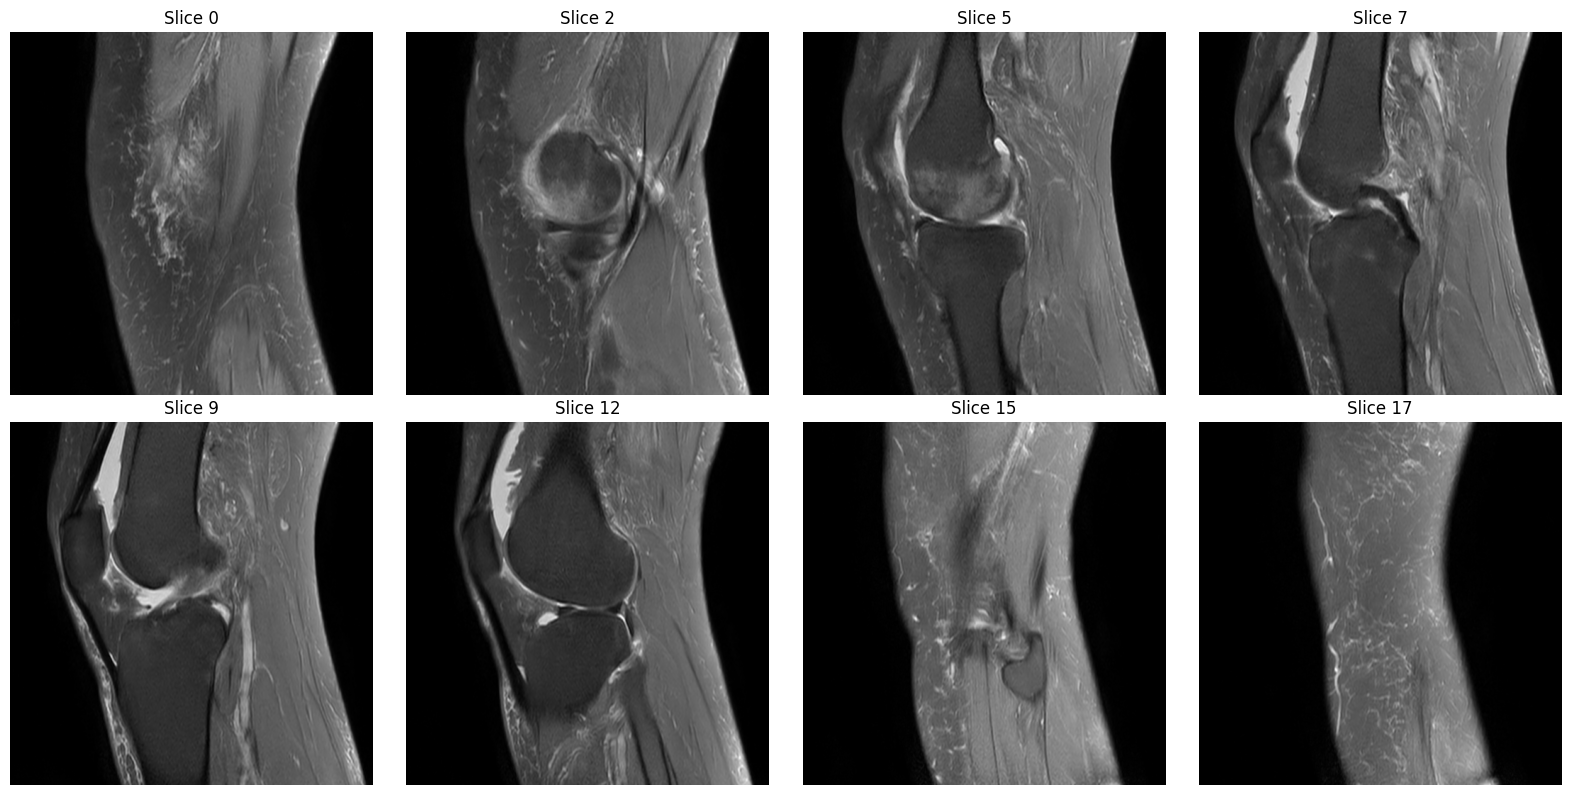

In [ ]:
## Display the volume - different cross sections of the same 3D MRI volume
fig, axes = plt.subplots(2, 4, figsize=(16, 8))             # this creates 1 figure, 8 plotting areas(axes), arranged as 2 rows x 4 columns

indices = [0, 2, 5, 7, 9, 12, 15, 17]                       # choose which slices to display

for ax, idx in zip(axes.ravel(), indices):                  # axes.ravel() = flatten the 2d axes grid, 'zip' parirs the axes with our slice indices
    ax.imshow(volume[idx], cmap="gray")                     # we are taking one slice of the volume we created above
    ax.set_title(f"Slice {idx}")
    ax.axis("off")

plt.tight_layout()                                          # automatically adjusts images so they don't overlap
plt.show()

In [ ]:
## Sanity check on the physical spacing between MRI Slices

distances = np.array([x["distance"] for x in slice_info])              # collect all distances, first pull out one dictionary from the list, then extract distance using the key x['distance']

adjacent_distances = np.diff(distances)                                # calculate distances between neighboring slices
                                                                       # we are measuring distance along the slice-normal and not IPPi

print("Adjacent slice spacings (mm):")
for i, d in enumerate(adjacent_distances):                             # enumerate gives index and value
    print(f"Slice {i} → Slice {i+1}: {d:.3f} mm")                      # print distance between two slices upto 3 decimals

print("\nMean spacing:", adjacent_distances.mean(), "mm")
print("Min spacing: ", adjacent_distances.min(), "mm")
print("Max spacing: ", adjacent_distances.max(), "mm")

Adjacent slice spacings (mm):
Slice 0 → Slice 1: 4.635 mm
Slice 1 → Slice 2: 9.269 mm
Slice 2 → Slice 3: 9.269 mm
Slice 3 → Slice 4: 4.635 mm
Slice 4 → Slice 5: 4.635 mm
Slice 5 → Slice 6: 4.635 mm
Slice 6 → Slice 7: 4.635 mm
Slice 7 → Slice 8: 4.635 mm
Slice 8 → Slice 9: 4.635 mm
Slice 9 → Slice 10: 4.635 mm
Slice 10 → Slice 11: 4.635 mm
Slice 11 → Slice 12: 4.635 mm
Slice 12 → Slice 13: 9.269 mm
Slice 13 → Slice 14: 4.635 mm
Slice 14 → Slice 15: 4.635 mm
Slice 15 → Slice 16: 4.635 mm
Slice 16 → Slice 17: 4.635 mm

Mean spacing: 5.452415758642315 mm
Min spacing:  4.63454193014428 mm
Max spacing:  9.269114432104345 mm


In [111]:
ds = pydicom.dcmread(files_on_disk[0])

print("SliceThickness:",
      getattr(ds, "SliceThickness", "Not present"))              # getattr is like ds.SliceThickness, if doesn't exist return Not Present

print("SpacingBetweenSlices:",
      getattr(ds, "SpacingBetweenSlices", "Not present"))

print("PixelSpacing:",
      ds.PixelSpacing)

SliceThickness: 3.4
SpacingBetweenSlices: 4.635
PixelSpacing: [0.330078125, 0.330078125]


### Looking at Pixel Values and transforming them (not really required to understand the MRI by the NN)

In [112]:
ds = pydicom.dcmread(files_on_disk[0])

tags = [
    "BitsAllocated",
    "BitsStored",
    "HighBit",
    "PixelRepresentation",
    "RescaleIntercept",
    "RescaleSlope",
    "WindowCenter",
    "WindowWidth",
]

for tag in tags:
    value = getattr(ds, tag, 'not present')
    print(f"{tag}: {value}")

BitsAllocated: 16
BitsStored: 12
HighBit: 11
PixelRepresentation: 0
RescaleIntercept: 0
RescaleSlope: 2.55507
WindowCenter: 959
WindowWidth: 1667


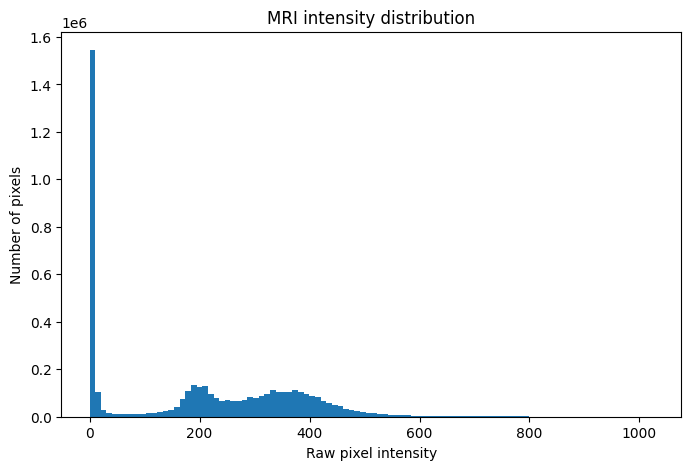

In [113]:
## looking at intensity distribution

plt.figure(figsize=(8,5))

plt.hist(volume.ravel(), bins=100)

plt.xlabel("Raw pixel intensity")
plt.ylabel("Number of pixels")
plt.title("MRI intensity distribution")

plt.show()

In [ ]:
## huge spike at I = 0, i.e. almost certainly the background outside the patient's body
## so the entire numerical range of 0-1025 is not spread equally
## another issue becomes when two people have different physiological structures like difference in muscle mass or cartilage
## the pixel intensities for both will be very different
## so we care more about the "relative contrast and spatial patterns"
## Therefore, MRIs use image or volume specific intensity normalization

In [ ]:
## Our tags earlier gave us an important piece of information:
## BitsAllocated = 16 i.e. DICOM gives each pixel a 16 bit storage container which means the 
   ## which means the cimputers reserves 2^16 = 65,536 possible integer values
## BitsStored = 12 i.e. only 12 bits actually contain meaningful stored pixel information
   ## Therefore maximum possible stored value: 2^16 - 1 = 4095
   ## and our particular volume only reached intensity ranging from 0 to 1025 (perfectly normal)
## PixelRepresentation=0 tells us that the stored values are unsigned integers
## RescaleSlope=2.55507 >> very important 
   ## DICOM defines a transformation i.e. (I_rescaled) = (I_stored * 2.55507) + (0)
   ## it implies a stored pixel value of 1025 = 1025 * 2.55507 = 2619.45

In [120]:
## Just because ds.RescaleSlope exists doesn't mean pixel values will be transformed automatically

from pydicom.pixel_data_handlers.util import apply_modality_lut           # this module takes the raw/stored DICOM pixel values and applies the modality LUT/rescale information encoded in the DICOM metadata, when applicable

ds = pydicom.dcmread(files_on_disk[0])                                    # read the DICOM

stored = ds.pixel_array.astype(np.float32)                                # read the stored pixel values and convert to float32 to perform numerical transformations

rescaled = apply_modality_lut(ds.pixel_array, ds).astype(np.float32)      # apply modality, the point of this modality is that it consults the relevant DICOM metadata on exactly how to apply the modality, if it is defined

print("Stored:")
print("  min:", stored.min())
print("  max:", stored.max())

print("\nRescaled:")
print("  min:", rescaled.min())
print("  max:", rescaled.max())

Stored:
  min: 0.0
  max: 889.0

Rescaled:
  min: 0.0
  max: 2271.4573


<function matplotlib.pyplot.show(close=None, block=None)>

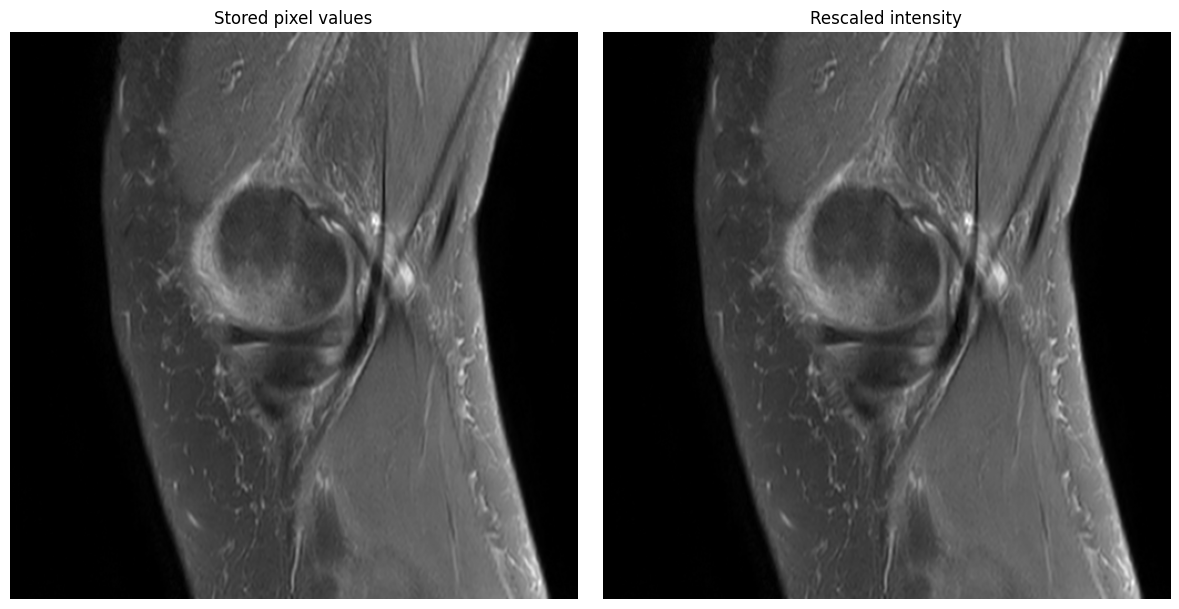

In [ ]:
## plot the image
fig, axes = plt.subplots(1,2, figsize=(12,6))      # fig is the 'whole canvas' and axes contains the 'individual plotting' (nrows, ncols), widhth = 12 inches and height = 6 inches

axes[0].imshow(stored, cmap='gray')               # display the "stored" pixel values array in the left subplot
axes[0].set_title("Stored pixel values")
axes[0].axis('off')

axes[1].imshow(rescaled, cmap='gray')             # display the rescaled image in the right suboplot
axes[1].set_title("Rescaled intensity")
axes[1].axis('off')

plt.tight_layout()
plt.show

## The reason it does not do anything is because rescaling is just a linear transformation,
## only numbers are changed 

### MRI Intensity Normalization

In [ ]:
## we need normalization because 0 - 200 - 400 pixel intensitities can be compressed to 0 - 0.5 - 1.
## these are numerically smoother for a NN to work with while preserving the realtive intensitiy structure
## Also pixel = 300, is not the same for every MRI study, and thus a standard normalization for the whole dataset won't work
## solution = per volume normalization
## also, we need to avoid the pixel = 0 (background) values, because otherwise they will dominate the mean and std stats
## so only normalize the actual image

In [ ]:
nonzero = volume[volume > 0].astype(np.float32)     # remember volume was are stack of 18 MRI slices
                                                    # non-zero voxels only
                                                    # also this will be a 1D array containing only positive voxel intensities

mean_intensity = nonzero.mean()
std_intensity = nonzero.std()

print("Non-zero mean:", mean_intensity)
print("Non-zero std: ", std_intensity)
print("Number of non-zero voxels:", len(nonzero))

Non-zero mean: 214.04294
Non-zero std:  172.92815
Number of non-zero voxels: 4425343


In [128]:
normalized_volume = np.zeros_like(volume, dtype=np.float32)   # create an empty normalized volume
                                                              # same shape as volume, but filled with zeros

mask = volume > 0                                             # created as boolean mask: True if intensity > 0, False otherwise

normalized_volume[mask] = (                                   # z-score normalization
    volume[mask].astype(np.float32) - mean_intensity
)/std_intensity

In [129]:
print("Normalized mean:", normalized_volume[mask].mean())
print("Normalized std: ", normalized_volume[mask].std())
print("Normalized min:", normalized_volume[mask].min())
print("Normalized max:", normalized_volume[mask].max())

Normalized mean: 3.1619106e-07
Normalized std:  1.0000002
Normalized min: -1.2319738
Normalized max: 4.689561


### Visualize the Raw_volume vs Normalized_volume side by side

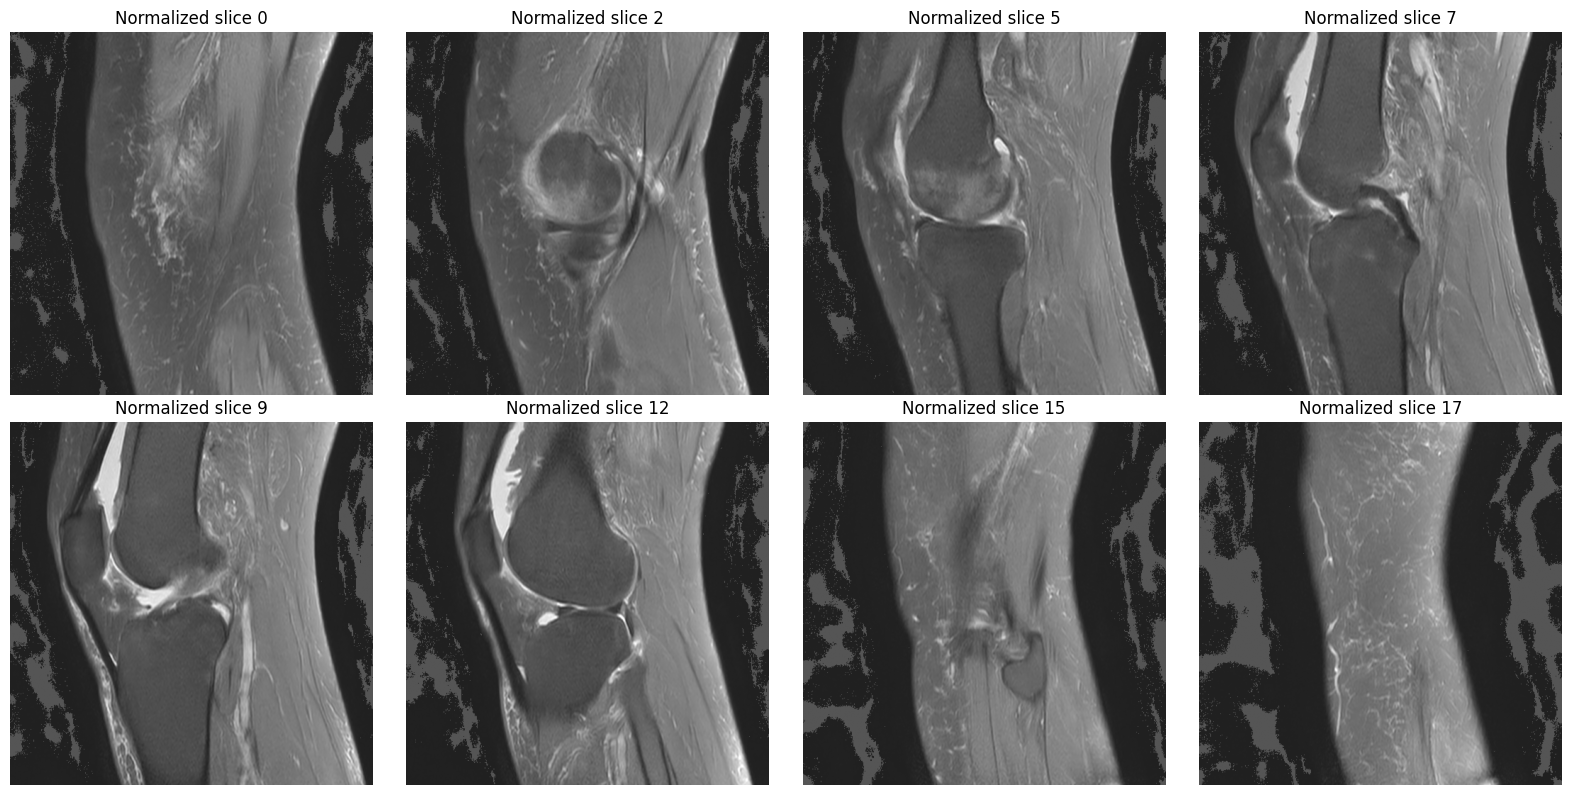

In [ ]:
fig, axes = plt.subplots(2,4, figsize=(16,8))           # we have a 'fig' = overall figure and 
                                                        # a collection of 'axes' = the individual places we can plot 

indices = [0, 2, 5, 7, 9, 12, 15, 17]

for ax, idx in zip(axes.ravel(), indices):      # currently  axes is 2D i.e. 2 rows x 4 colums, 
                                                # we unravel or flatten this 2D array into 1D
                                                # shape changes from (2,8) to (8,)
                                                # because we want to loop through the 8 plotting areas one after another
                                                # axes.ravel() gives [A,B,C....H] and indices gives [0, 2, .... 17]
                                                # zip() pair them together (A-0), (B-2)....
    ax.imshow(normalized_volume[idx], cmap='gray',
              vmin=-2,
              vmax=4)
    ax.set_title(f"Normalized slice {idx}")
    ax.axis('off')

plt.tight_layout()
fig.canvas.draw()
plt.show()

### Series - Moving up in the Hierarchy

In [ ]:
## Now that we understand 